In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

## Part b

In [2]:

from partb import build_part_b_dataset, build_part_b_split, split_summary

df = build_part_b_dataset()
split_summary(df)

monthly_early, daily_recent, combined = build_part_b_split()

In [3]:
daily_recent.head()

,year_month,Date,Open,High,Low,Close,Volume,granularity
0,NaN,2016-03-01,1937.09,1978.35,1937.09,1978.35,2677638889,daily
1,NaN,2016-03-02,1976.60,1986.51,1968.80,1986.45,2592561111,daily
2,NaN,2016-03-03,1985.60,1993.69,1977.37,1993.40,2823166667,daily
3,NaN,2016-03-04,1994.01,2009.13,1986.77,1999.99,3361072222,daily
4,NaN,2016-03-07,1996.11,2006.12,1989.38,2001.76,2760100000,daily


In [4]:
# t-GARCH on daily_recent: needs `arch` in this notebook's Python env.
# In terminal (from project folder): .venv/bin/pip install arch
# In Jupyter: pick kernel "Python (.venv)" or similar so imports find `partb`.

from partb import (
    compute_log_returns,
    fit_t_garch_on_daily_recent,
    compare_garch_orders,
)

log_r = compute_log_returns(daily_recent)
log_r.head(), len(log_r)


(2016-03-02    0.004086
 2016-03-03    0.003493
 2016-03-04    0.003300
 2016-03-07    0.000885
 2016-03-08   -0.011304
 Name: log_return, dtype: float64,
 2513)

## 1. If you have multiple approaches at least one of them should be the construction/simulation of daily data. (DAILY CONSTRUCTION ESTIMATION)

In [5]:
# Fit GARCH(1,1)-t (default); use garch.fit for simulation later.
garch = fit_t_garch_on_daily_recent(daily_recent)
garch.params, garch.scale


({'mu': 0.0979265573355916,
  'omega': 0.020558961909627395,
  'alpha[1]': 0.16719792930117114,
  'beta[1]': 0.8302108794924186,
  'nu': 5.016668668801989},
 100.0)

In [6]:
# Optional: (1,1) vs (2,1) vs (1,2) by BIC + Ljung–Box on z^2 for chosen model
sel = compare_garch_orders(daily_recent)
sel["criteria_table"]


,p,q,loglikelihood,aic,bic,converged
0,1,1,-3106.345951,6222.691902,6251.838064,True
1,2,1,-3106.245009,6224.490018,6259.465413,True
2,1,2,-3106.345951,6224.691901,6259.667296,True


In [7]:
sel["model_selection_note"], sel["chosen_order"]
sel["ljung_box_sq_std_residuals"]


,lb_stat,lb_pvalue
1,0.769430,0.380393
2,1.082749,0.581948
3,1.126661,0.770642
4,3.817151,0.431317
5,4.464331,0.484670
6,4.920436,0.554058
7,7.127586,0.415718
8,8.442577,0.391473
9,10.436926,0.316284
10,11.067224,0.352305


In [8]:
# PARTB_2: bridged daily paths + drawdown Monte Carlo (see partb_sim.py)
from partb import load_spx_daily
from partb_sim import partb2_monte_carlo, partb2_month_table

daily_full = load_spx_daily()
month_tbl = partb2_month_table(monthly_early, daily_full)
month_tbl.head()


,date_start,date_end,close_start,close_end,R_month_log,n_days
0,1976-03-31,1976-04-30,102.77,101.64,-0.011056,21
1,1976-04-30,1976-05-28,101.64,100.18,-0.014469,20
2,1976-05-28,1976-06-30,100.18,104.28,0.040111,22
3,1976-06-30,1976-07-30,104.28,103.44,-0.008088,21
4,1976-07-30,1976-08-31,103.44,102.91,-0.005137,22



=== 1 calendar month (SPX historical) ===
Observations: 12603
  mean=0.008030  median=0.011533  skew=-0.7388  kurtosis(excess)=4.4977
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.043700
    p5: -0.065117
    p1: -0.116013
  Right tail (p90/p95/p99):
    p90: 0.055299
    p95: 0.071111
    p99: 0.113463

=== 3 calendar months (SPX historical) ===
Observations: 12603
  mean=0.024117  median=0.029003  skew=-0.5413  kurtosis(excess)=2.6888
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.064827
    p5: -0.102023
    p1: -0.211716
  Right tail (p90/p95/p99):
    p90: 0.105681
    p95: 0.132625
    p99: 0.194514

=== 6 calendar months (SPX historical) ===
Observations: 12603
  mean=0.048637  median=0.053740  skew=-0.4566  kurtosis(excess)=1.7732
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.079673
    p5: -0.121502
    p1: -0.278686
  Right tail (p90/p95/p99):
    p90: 0.174819
    p95: 0.

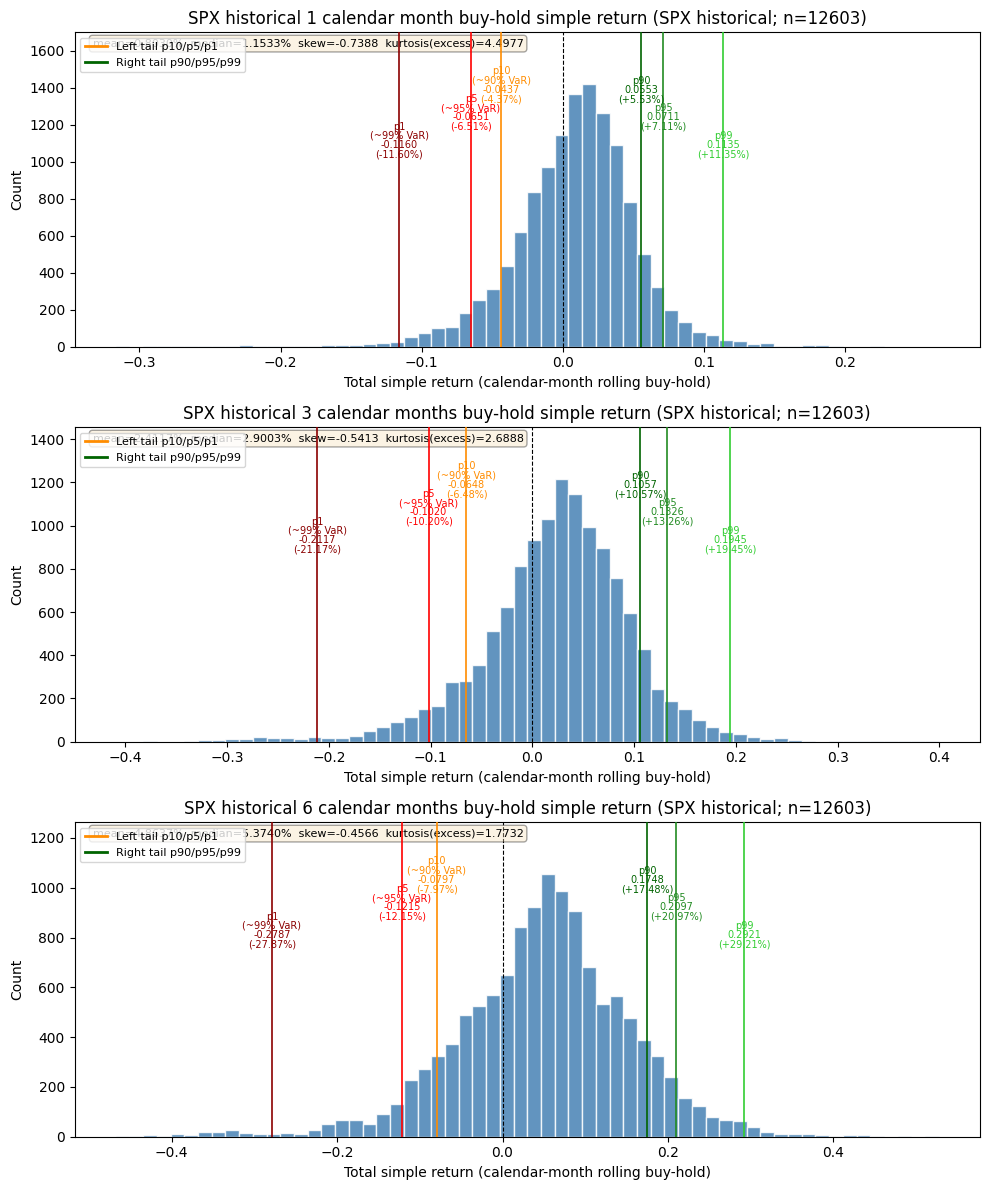

{'return_p1': -0.2786860445907438,
 'return_p5': -0.12150180816623589,
 'return_p10': -0.07967293638928041,
 'loss_magnitude_p99': 0.2786860445907438,
 'loss_magnitude_p95': 0.12150180816623589,
 'loss_magnitude_p90': 0.07967293638928041,
 'return_p90': 0.17481941580362848,
 'return_p95': 0.20974704164389588,
 'return_p99': 0.2920647809393254,
 'gain_magnitude_p90': 0.17481941580362848,
 'gain_magnitude_p95': 0.20974704164389588,
 'gain_magnitude_p99': 0.2920647809393254}

In [9]:
from spx_trading_day_buyhold import analyze_historical_calendar_month_buyhold_percentiles

cal_hist = analyze_historical_calendar_month_buyhold_percentiles(show_plots=True)
cal_hist[1]["tail_metrics"]   # 1-month
cal_hist[3]["tail_metrics"]   # 3-month
cal_hist[6]["tail_metrics"]   # 6-month


=== 1 calendar month (simulated pooled) ===
Observations: 1006600
  mean=0.007937  median=0.008453  skew=89.9773  kurtosis(excess)=27735.6266
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.050735
    p5: -0.073733
    p1: -0.138449
  Right tail (p90/p95/p99):
    p90: 0.063757
    p95: 0.083297
    p99: 0.139605

=== 3 calendar months (simulated pooled) ===
Observations: 1006600
  mean=0.022253  median=0.024056  skew=38.2037  kurtosis(excess)=8803.9287
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.074653
    p5: -0.114710
    p1: -0.226924
  Right tail (p90/p95/p99):
    p90: 0.115456
    p95: 0.144683
    p99: 0.217365

=== 6 calendar months (simulated pooled) ===
Observations: 1006600
  mean=0.044358  median=0.046318  skew=16.7868  kurtosis(excess)=2965.4297
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.089753
    p5: -0.137038
    p1: -0.305586
  Right tail (p90/p95/p99):
    p90

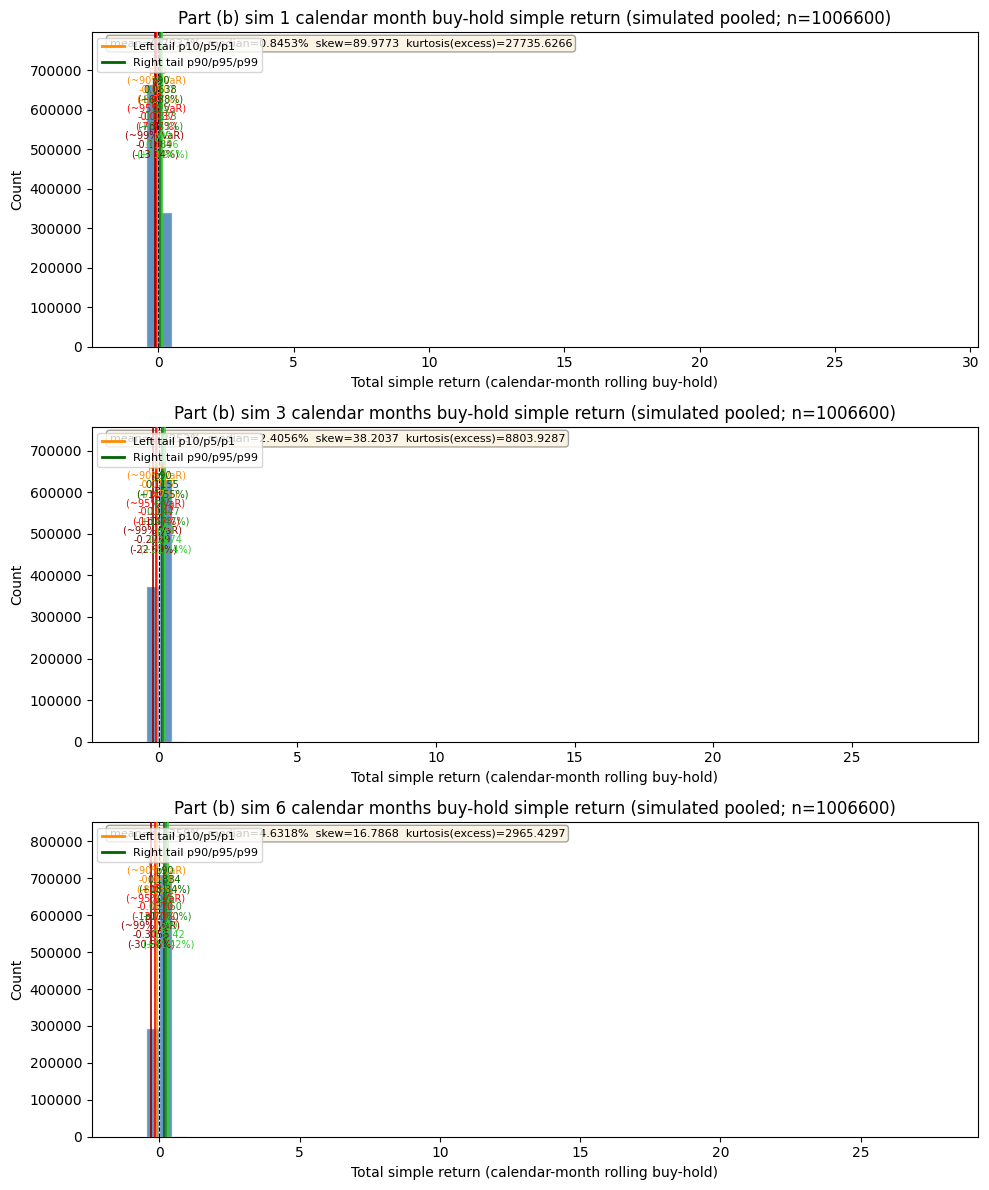

{'return_p1': -0.3055860123834947,
 'return_p5': -0.13703818158310271,
 'return_p10': -0.08975346279802149,
 'loss_magnitude_p99': 0.3055860123834947,
 'loss_magnitude_p95': 0.13703818158310271,
 'loss_magnitude_p90': 0.08975346279802149,
 'return_p90': 0.18342307144101924,
 'return_p95': 0.2259796544197957,
 'return_p99': 0.3141642863026681,
 'gain_magnitude_p90': 0.18342307144101924,
 'gain_magnitude_p95': 0.2259796544197957,
 'gain_magnitude_p99': 0.3141642863026681}

In [10]:
from spx_trading_day_buyhold import analyze_partb2_simulated_calendar_month_buyhold

cal_bh = analyze_partb2_simulated_calendar_month_buyhold(
    monthly_early, daily_full, garch,
    n_paths=100,
    seed=42,
    show_plots=True,
)
cal_bh[1]["tail_metrics"]
cal_bh[3]["tail_metrics"]
cal_bh[6]["tail_metrics"]